In [82]:
import pandas as pd
import matplotlib.pyplot as plt

In [83]:
df = pd.read_csv("C:/projects/P1/final_summary.csv")

In [84]:
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

cols = ["total_sales","total_units","avg_inventory","avg_demand","avg_discount"]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=cols)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34268 entries, 0 to 34268
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               34268 non-null  object 
 1   Store_ID           34268 non-null  object 
 2   Region             34268 non-null  object 
 3   Category           34268 non-null  object 
 4   Seasonality        34268 non-null  object 
 5   Promotion          34268 non-null  int64  
 6   Weather_Condition  34268 non-null  object 
 7   total_sales        34268 non-null  float64
 8   total_units        34268 non-null  int64  
 9   avg_inventory      34268 non-null  float64
 10  avg_demand         34268 non-null  float64
 11  avg_discount       34268 non-null  float64
dtypes: float64(4), int64(2), object(6)
memory usage: 3.4+ MB


In [85]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

<Figure size 640x480 with 0 Axes>

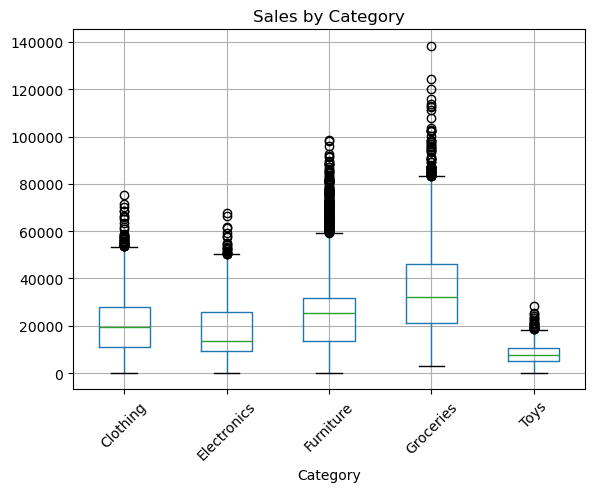

In [86]:
plt.figure()

df.boxplot(column="total_sales", by="Category", rot=45)

plt.title("Sales by Category")
plt.suptitle("")
plt.show()

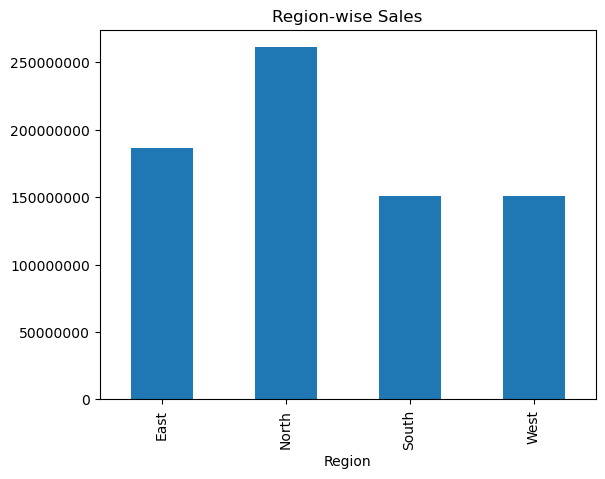

In [87]:
region_sales = df.groupby('Region')['total_sales'].sum()

region_sales.plot(kind='bar')
plt.title("Region-wise Sales")
plt.show()

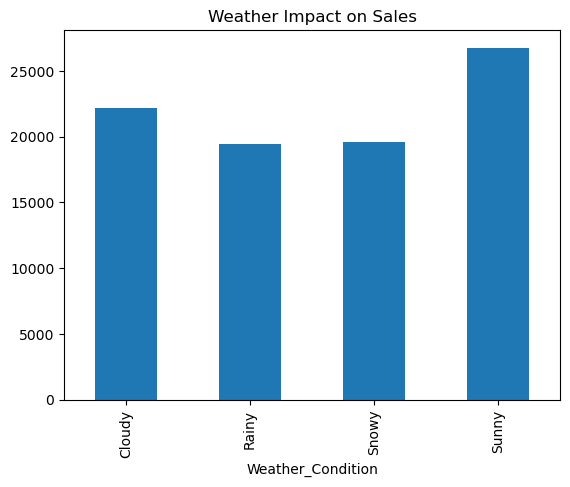

In [88]:
weather = df.groupby("Weather_Condition")["total_sales"].mean()

weather.plot(kind="bar")
plt.title("Weather Impact on Sales")
plt.show()

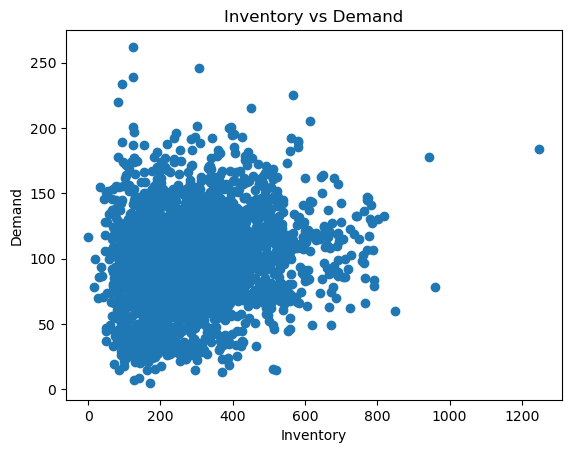

In [89]:
sample = df.sample(5000)

plt.figure()
plt.scatter(sample["avg_inventory"], sample["avg_demand"])
plt.xlabel("Inventory")
plt.ylabel("Demand")
plt.title("Inventory vs Demand")
plt.show()

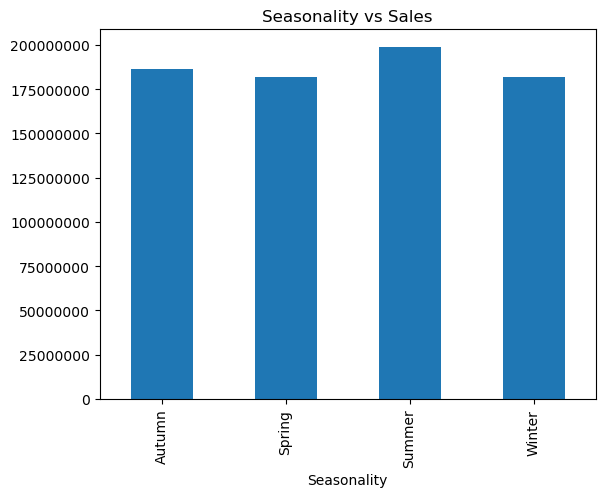

In [90]:
season = df.groupby("Seasonality")["total_sales"].sum()

season.plot(kind="bar")
plt.title("Seasonality vs Sales")
plt.show()

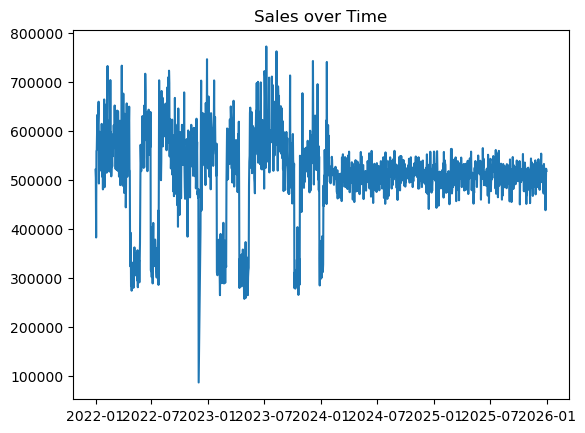

In [91]:
date_sales = df.groupby("Date")["total_sales"].sum()

plt.figure()
plt.plot(date_sales)
plt.title("Sales over Time")
plt.show()

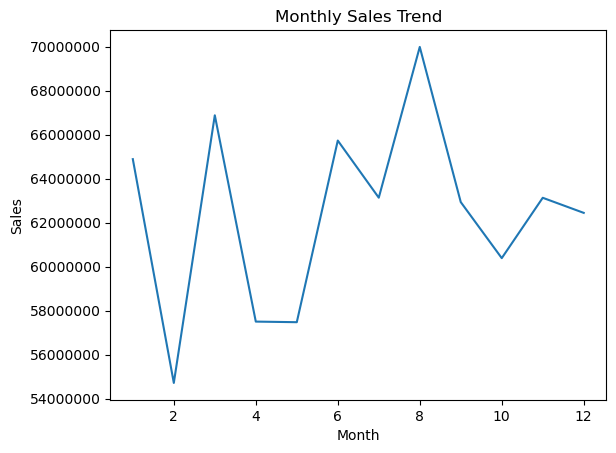

In [92]:
df["Month"] = df["Date"].dt.month

month_sales = df.groupby("Month")["total_sales"].sum()

plt.figure()
plt.plot(month_sales.index, month_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

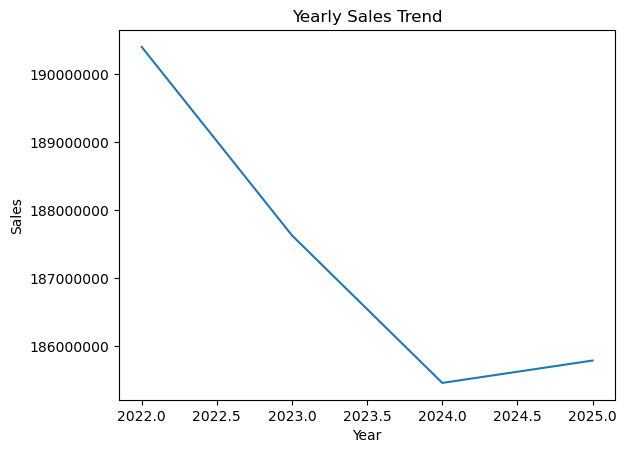

In [93]:
df["Year"] = df["Date"].dt.year

year_sales = df.groupby("Year")["total_sales"].sum()

plt.figure()
plt.plot(year_sales.index, year_sales.values)
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

In [94]:
df.to_csv("C:/projects/P1/dashboard_data.csv", index=False)